# Mach2 grey-diffusion radiative shock: reading & analytic fit

RadHydroMach2 (single-group/grey diffusion Mach2 radiative shock) snapshots loaded directly with `richio`, compared against the analytic NLTE radiative-shock solution (Lowrie & Edwards 2008) from `analysis_files/radiative_shock`.

This run uses **raw cgs units directly**, not richio's Msun/Rsun/G=1 code-unit system used for TDE runs -- so fields are taken as bare floats out of the `unyt_array` (never `.in_cgs()`/`.to(...)`, which would apply the wrong scale).

Batch version (scans every snapshot, writes the summary table + per-snapshot figures used below) lives in `scripts/mach2_radiative_shock_scan.py` -- rerun that to refresh after a new sim, tune/explore here.

In [1]:
import glob
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

import richio, dev

sys.path.insert(0, os.path.abspath("../../scripts"))
from nlte_radiative_shock import NLTERadiativeShock
from radiative_shock import Units

## Config

Left (unshocked, downstream) state and opacities -- must match `runs/RadHydroMach2/test.cpp`.

In [2]:
INPUT_DIR = "/home/hey4/RICH/alice_data/raw/RadHydroMach2"

GAMMA = 5.0 / 3.0
MU = 1.67e-24  # g, mean particle mass
K_BOLTZ = 1.380649e-16  # erg/K
CV = K_BOLTZ / (MU * (GAMMA - 1.0))

RHO_LEFT = 5.45887e-13  # g/cc
V_LEFT = 2.3547e5  # cm/s
T_LEFT = 100.0  # K
SIGMA_ROSS = 0.848902  # 1/cm
SIGMA_ABS = 3.93e-5  # 1/cm

CS_LEFT = np.sqrt(GAMMA * (GAMMA - 1.0) * CV * T_LEFT)
M0 = V_LEFT / CS_LEFT

solver = NLTERadiativeShock(
    M0=M0,
    gamma=GAMMA,
    sigma_ross=lambda T, rho: SIGMA_ROSS,
    sigma_abs=lambda T, rho: SIGMA_ABS,
    cv=CV,
    rho_left=RHO_LEFT,
    v_left=V_LEFT,
    T_left=T_LEFT,
    eps_nlte_solver=1e-4,
)

INFO:RadiativeShock:creating a RadiativeShock calculator...


INFO:RadiativeShock:gamma=1.66667


INFO:RadiativeShock:M0=2.00599


INFO:RadiativeShock:P0=0.000100585


INFO:RadiativeShock:downstream (unshocked, left) state: rho=5.45887e-13[g/cc] T=100[K]=8.617333e-06[keV] v=235470[cm/s]


...

INFO:RadiativeShock:matter ideal gas (gamma=1.66667) dominated compression 2.29162


INFO:RadiativeShock:radiation ideal gas (gamma=4/3) dominated compression 2.92538


INFO:RadiativeShock:calculated mach=(v_shock-v_left)/cs_left=2.00599 while given mach M0=2.00599 err=0


INFO:NLTERadiativeShock:creating a NLTERadiativeShock calculator...


Precursor region
Relaxation region
Discontinuous case: embedded hydrodynamic shock


## Load one snapshot

Pick any `Mach2_*.h5` file -- change `SNAP` and rerun.

In [3]:
files = sorted(glob.glob(os.path.join(INPUT_DIR, "Mach2_*.h5")))
print(f"{len(files)} snapshots available, e.g.:")
print([os.path.basename(f) for f in files[:5]], "...")

SNAP = "Mach2_final.h5"
snap = richio.load(os.path.join(INPUT_DIR, SNAP))

# Raw cgs values (see note above -- no unit conversion)
x_num = np.asarray(snap.x)
rho_num = np.asarray(snap.density)
T_num = np.asarray(snap.temperature)
Erad_num = np.asarray(snap.Erad)  # specific radiation energy [erg/g]
Trad_num = (Erad_num * rho_num / Units.arad) ** 0.25
diss_num = np.asarray(snap.dissipation * snap.volume)
t = float(np.asarray(snap.time))

order = np.argsort(x_num)
x_num, rho_num, T_num, Trad_num, diss_num = (
    x_num[order], rho_num[order], T_num[order], Trad_num[order], diss_num[order],
)

print(f"{SNAP}: t={t:.4e}s, {len(x_num)} cells")

133 snapshots available, e.g.:
['Mach2_0.h5', 'Mach2_100.h5', 'Mach2_1000.h5', 'Mach2_10000.h5', 'Mach2_10100.h5'] ...
Mach2_final.h5: t=2.0000e-02s, 1024 cells


## Analytic fit at this snapshot's time

In [4]:
solution = solver.solve_profiles(time=t, x=x_num)
rho_ana = solution["density"]
T_ana = solution["temperature"]
Trad_ana = solution["radiation_temperature"]
v_ana = solution["velocity"]


def rel_l1_error(numeric, analytic):
    """Per-cell relative L1 error: mean(|num - ana| / |num|), shocked region only."""
    mask = np.abs(numeric) > 0.01 * np.max(np.abs(numeric))
    if np.sum(mask) < 2:
        mask = np.ones(len(numeric), dtype=bool)
    return float(np.mean(np.abs(numeric[mask] - analytic[mask]) / np.abs(numeric[mask])))


print(f"density_L1 = {rel_l1_error(rho_num, rho_ana):.4e}")
print(f"Tgas_L1    = {rel_l1_error(T_num, T_ana):.4e}")
print(f"Trad_L1    = {rel_l1_error(Trad_num, Trad_ana):.4e}")

density_L1 = 2.6124e-03
Tgas_L1    = 3.5088e-03
Trad_L1    = 3.0146e-03


## Profile comparison plot

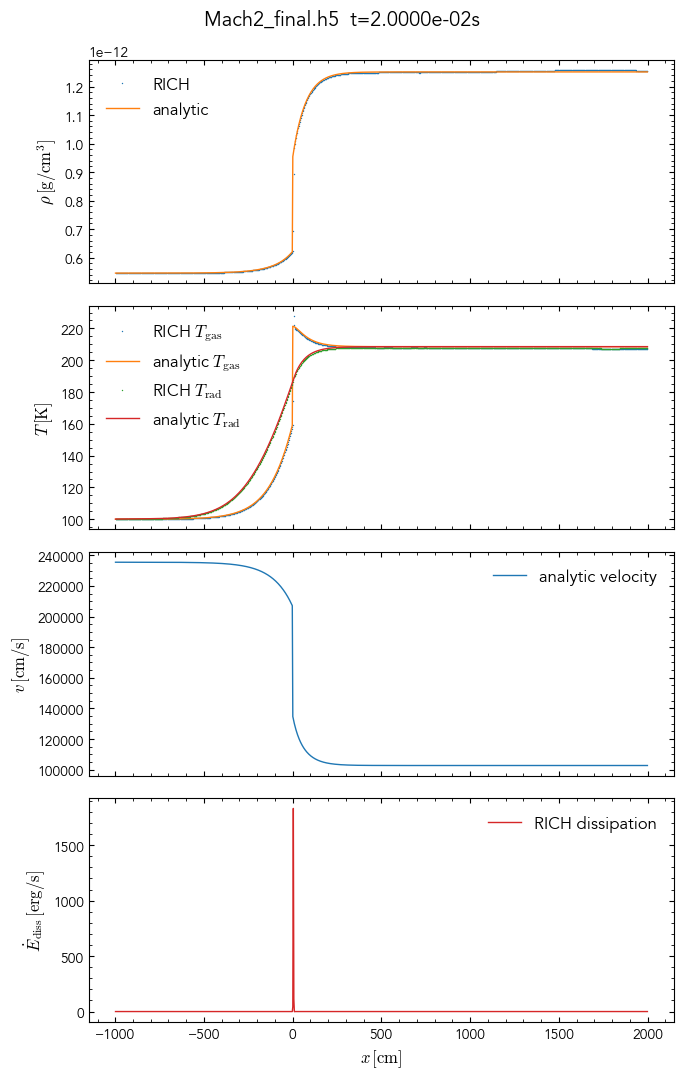

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(7, 11), sharex=True)

axes[0].plot(x_num, rho_num, ".", ms=2, label="RICH")
axes[0].plot(x_num, rho_ana, "-", label="analytic")
axes[0].set_ylabel(r"$\rho\,\mathrm{[g/cm^3]}$")
axes[0].legend()

axes[1].plot(x_num, T_num, ".", ms=2, label=r"RICH $T_\mathrm{gas}$")
axes[1].plot(x_num, T_ana, "-", label=r"analytic $T_\mathrm{gas}$")
axes[1].plot(x_num, Trad_num, ".", ms=2, label=r"RICH $T_\mathrm{rad}$")
axes[1].plot(x_num, Trad_ana, "-", label=r"analytic $T_\mathrm{rad}$")
axes[1].set_ylabel(r"$T\,\mathrm{[K]}$")
axes[1].legend()

axes[2].plot(x_num, v_ana, "-", label="analytic velocity")
axes[2].set_ylabel(r"$v\,\mathrm{[cm/s]}$")
axes[2].legend()

axes[3].plot(x_num, diss_num, "-", ms=2, color="C3", label="RICH dissipation")
axes[3].set_ylabel(r"$\dot{E}_\mathrm{diss}\,\mathrm{[erg/s]}$")
axes[3].set_xlabel(r"$x\,\mathrm{[cm]}$")
axes[3].legend()

fig.suptitle(f"{SNAP}  t={t:.4e}s")
fig.tight_layout()
plt.show()

Analytical work

In [6]:
# Verification of equation 23a
# Okay this is wrong rn, need to convert to dimensionless variable first
rho1 = solver.rho_right / RHO_LEFT
T1 = solver.T_right / T_LEFT
p0 = solver.p_right / rho1 / CS_LEFT**2
M0_23a = np.sqrt(
    (3 * rho1 * (1 - T1 * rho1) + GAMMA * p0 * (T1**4 - 1) * rho1)
    / (3 * GAMMA * (1 - rho1))
)
print(M0_23a)


2.0057200120937067


Hydrodynamical shock

In [7]:
import richio.shockfinder as sf
sf.M2R(M=2), sf.MT2T1(M=2)

(2.285714285714286, 2.078125)

In [8]:
rho1, T1

(np.float64(2.291933904925793), np.float64(2.0853310835494736))

In [9]:
import unyt as u

In [10]:
a_r = u.a.in_cgs().v
M0_momentum = np.sqrt(1/CS_LEFT**2 * rho1 / (rho1 - 1) / RHO_LEFT * (solver.p_right + 1/3 * a_r * solver.T_right**4 - solver.p_left - 1/3 * a_r * solver.T_left**4))
print(M0_momentum)

2.006251079912005


## Robustness

For every pair of cells $(i,j)$ in the profile, treat cell $i$ as the preshock state and cell $j$ as the postshock state and evaluate the same momentum-flux Mach number as above. Only $x_i < x_j$ is physical (preshock upstream of postshock), so the reversed half of the grid is masked out.

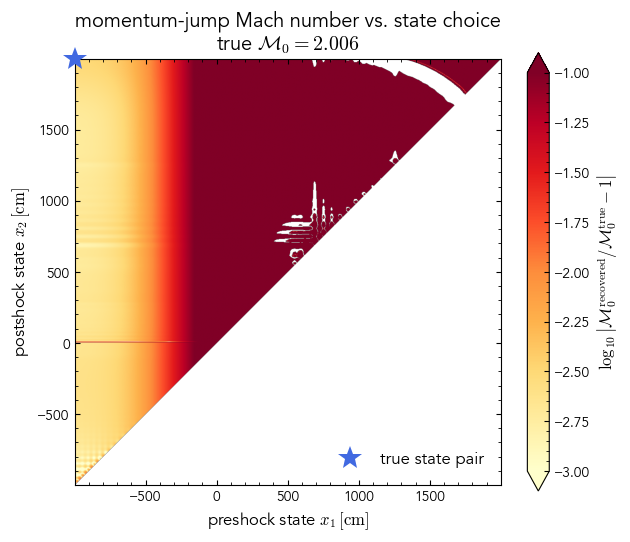

In [11]:
def total_pressure(rho, T, Erad):
    """Gas pressure (ideal-gas EOS) + radiation pressure P_rad = U_rad/3, using
    the radiation energy density directly from the sim (rho*Erad) rather than
    reconstructing it via a temperature. T_gas != T_rad out of LTE, so going
    through T**4 is both an unnecessary round-trip and, if you grab the wrong
    T (as an earlier version of this cell did, using T_gas), wrong."""
    return (GAMMA - 1.0) * rho * CV * T + rho * Erad / 3.0


def sound_speed(T):
    return np.sqrt(GAMMA * (GAMMA - 1.0) * CV * T)


p_num = total_pressure(rho_num, T_num, Erad_num)
cs_num = sound_speed(T_num)

rhoA, rhoB = rho_num[:, None], rho_num[None, :]  # rows=preshock i, cols=postshock j
pA, pB = p_num[:, None], p_num[None, :]
csA = cs_num[:, None]

with np.errstate(divide="ignore", invalid="ignore"):
    Mdot2 = (pB - pA) / (1.0 / rhoA - 1.0 / rhoB)
    M0_grid = np.sqrt(Mdot2) / (rhoA * csA)

i_idx, j_idx = np.meshgrid(np.arange(len(x_num)), np.arange(len(x_num)), indexing="ij")
valid = (j_idx > i_idx) & (Mdot2 > 0) & np.isfinite(M0_grid)
M0_grid = np.where(valid, M0_grid, np.nan)

rel_err = np.abs(M0_grid / solver.M0 - 1.0)
log_rel_err = np.log10(np.maximum(rel_err, 1e-6))
VMIN, VMAX = -3.0, -1.0

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(
    log_rel_err.T,  # transpose: rows(j)->y=postshock, cols(i)->x=preshock
    origin="lower",
    extent=[x_num[0], x_num[-1], x_num[0], x_num[-1]],
    aspect="equal",
    cmap="YlOrRd",
    vmin=VMIN,
    vmax=VMAX,
)
ax.plot(x_num[0], x_num[-1], "*", ms=18, mec="k", mfc="royalblue", label="true state pair", zorder=5, clip_on=False)

cbar = fig.colorbar(im, ax=ax, extend="both", label=r"$\log_{10}\left|\mathcal{M}_0^\mathrm{recovered}/\mathcal{M}_0^\mathrm{true} - 1\right|$")

ax.set_xlabel(r"preshock state $x_1\,\mathrm{[cm]}$")
ax.set_ylabel(r"postshock state $x_2\,\mathrm{[cm]}$")
ax.set_title(f"momentum-jump Mach number vs. state choice\ntrue $\\mathcal{{M}}_0={solver.M0:.3f}$")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

## Shock finder

In [12]:
# No actual voronoi tessellation in 1D
vor = sf.build_voronoi(snap, coords=("X",))
shock_zone = sf.find_shock_zone(snap, vor)
surface = sf.find_shock_surface(snap, vor, shock_zone)

# Finder masks are in snap's native cell order; reorder to the x-sorted profiles.
zone_s = shock_zone[order]
surf_s = surface.surface_mask[order]
pre_s = surface.pre_mask[order]
post_s = surface.post_mask[order]
divV_s = np.asarray(snap.divV)[order]
v_num = np.asarray(snap.Vx)[order]

print(f"shock-zone cells : {int(shock_zone.sum())}")
print(f"surface cells    : {int(surface.surface_mask.sum())}")
print(f"surface x [cm]   : {np.round(x_num[surf_s], 2)}")
for name in ("mach_T", "mach_P", "mach_rho"):
    m = getattr(surface, name)
    m = m[np.isfinite(m)]
    print(f"  {name:9s} median = {np.median(m):.3f}" if m.size else f"  {name:9s} (none)")
print(f"analytic upstream Mach M0 = {solver.M0:.3f}")

Building Voronoi for 1,024 cells (1D) ...


Done.  Mean neighbours/cell: 2.0


shock-zone cells : 1
surface cells    : 1
surface x [cm]   : [3.42]
  mach_T    median = 1.513
  mach_P    median = 1.359
  mach_rho  median = 1.298
analytic upstream Mach M0 = 2.006


The true shock is M = 2, shock finder reports M ≈ 1.3–1.5 (from the T, P and $\rho$ jumps)

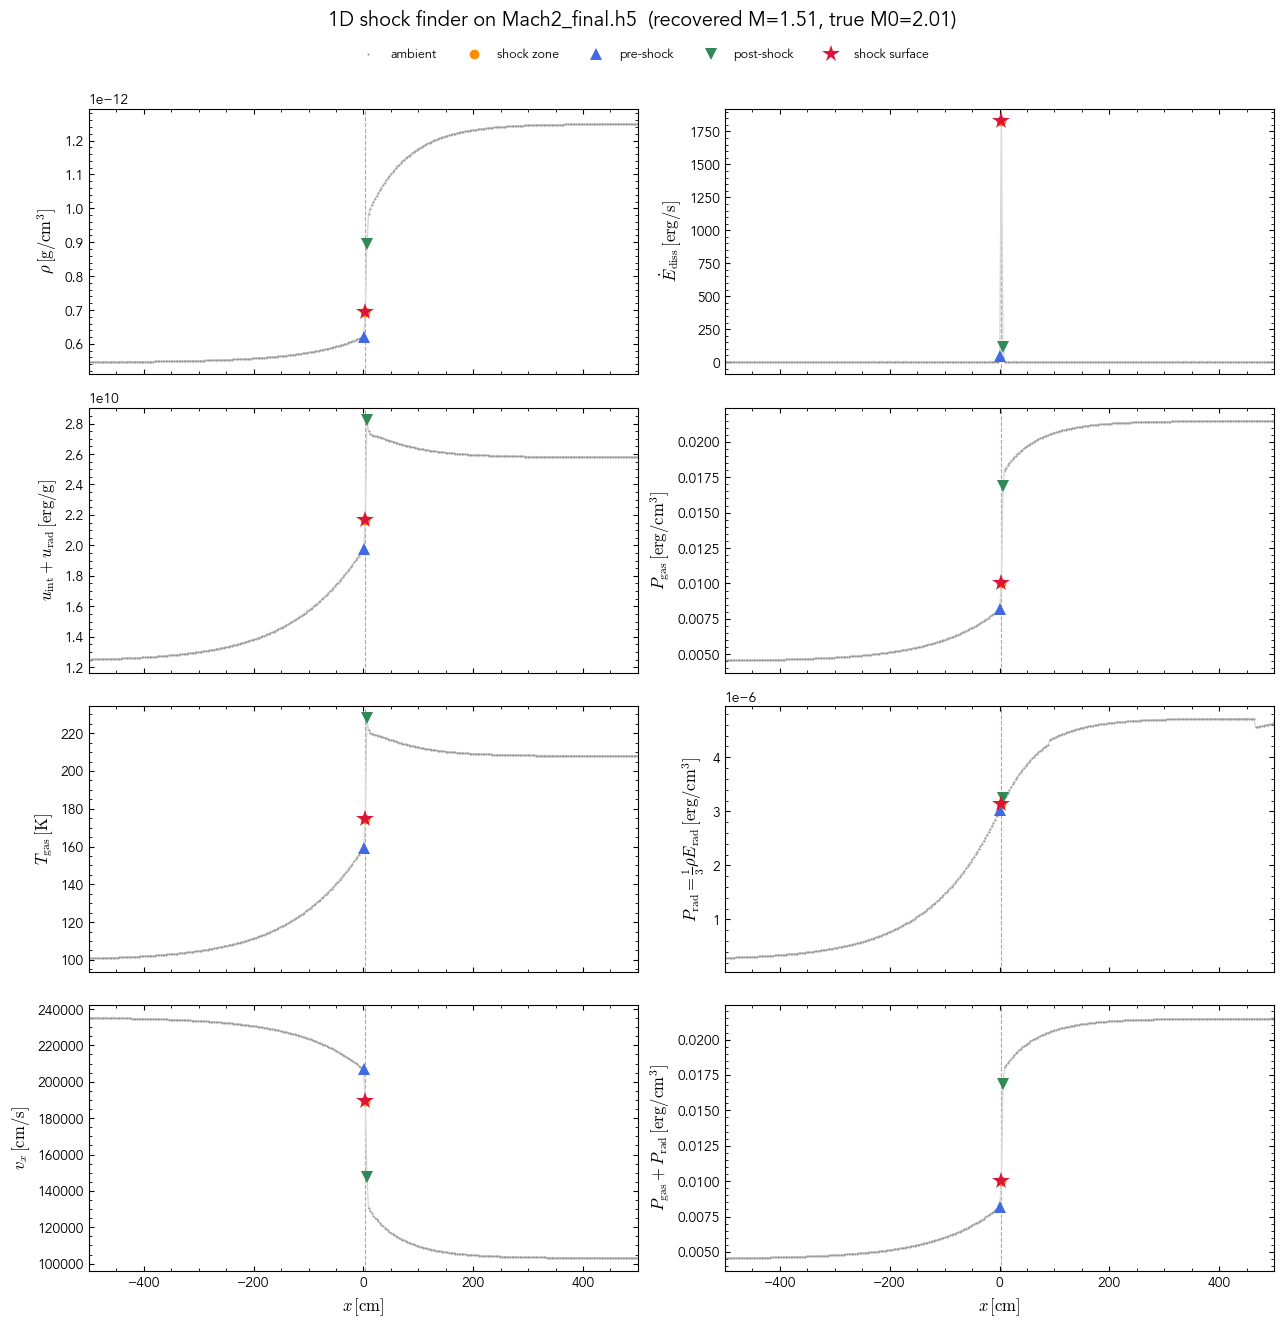

In [13]:
# Gas / radiation pressure from the x-sorted profiles.
Pgas = (GAMMA - 1.0) * rho_num * CV * T_num
Prad = rho_num * Erad_num / 3.0  # P_rad = U_rad/3, direct from the sim field (not via T**4)
Ptot = Pgas + Prad

# Specific internal and radiation energy, straight from the snapshot fields
# (both [erg/g]); reordered to the x-sorted profiles.
u_int = np.asarray(snap.InternalEnergy)[order]
u_rad = np.asarray(snap.Erad)[order]
u_tot = u_int + u_rad


def mark_states(ax, y):
    """Overlay the shock finder's per-cell state on a profile panel."""
    ax.plot(x_num, y, "-", color="0.85", lw=1, zorder=1)
    ax.plot(x_num, y, ".", color="0.6", ms=3, label="ambient", zorder=2)
    ax.plot(x_num[zone_s], y[zone_s], "o", color="darkorange", ms=7, label="shock zone", zorder=3)
    ax.plot(x_num[pre_s], y[pre_s], "^", color="royalblue", ms=8, label="pre-shock", zorder=4)
    ax.plot(x_num[post_s], y[post_s], "v", color="seagreen", ms=8, label="post-shock", zorder=4)
    ax.plot(x_num[surf_s], y[surf_s], "*", color="crimson", ms=13, mec="k", label="shock surface", zorder=5)
    for xs in x_num[surf_s]:
        ax.axvline(xs, color="crimson", lw=0.8, ls="--", alpha=0.5, zorder=0)


panels = [
    (rho_num, r"$\rho\,\mathrm{[g/cm^3]}$"),
    (u_tot, r"$u_\mathrm{int}+u_\mathrm{rad}\,\mathrm{[erg/g]}$"),
    (T_num, r"$T_\mathrm{gas}\,\mathrm{[K]}$"),
    (v_num, r"$v_x\,\mathrm{[cm/s]}$"),
    (diss_num, r"$\dot{E}_\mathrm{diss}\,\mathrm{[erg/s]}$"),
    (Pgas, r"$P_\mathrm{gas}\,\mathrm{[erg/cm^3]}$"),
    (Prad, r"$P_\mathrm{rad}=\frac{1}{3}\rho E_\mathrm{rad}\,\mathrm{[erg/cm^3]}$"),
    (Ptot, r"$P_\mathrm{gas}+P_\mathrm{rad}\,\mathrm{[erg/cm^3]}$"),
]

fig, axes = plt.subplots(4, 2, figsize=(13, 13), sharex=True)
for ax, (y, ylabel) in zip(axes.T.flat, panels):
    mark_states(ax, y)
    ax.set_ylabel(ylabel)
for ax in axes[-1, :]:
    ax.set_xlabel(r"$x\,\mathrm{[cm]}$")

axes[0, 0].set_xlim(-500, 500)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=6, fontsize=9, bbox_to_anchor=(0.5, 1.0))
fig.suptitle(f"1D shock finder on {SNAP}  (recovered M={np.median(surface.mach_T):.2f}, true M0={solver.M0:.2f})", y=1.02)
fig.tight_layout()
plt.show()